# ☀️ Interactive Simulator: UV Light and Cyanotypes

### Welcome, Chemists!
In the real world, we can't see Ultraviolet (UV) light with our eyes, but we can see what it *does* to chemicals. 

In this notebook, we will use code to build a virtual piece of Sunprint paper. We will place a virtual "Leaf" on it, turn on a virtual Sun, and watch the photochemistry happen step-by-step!

**Teacher Instructions:** Run the code blocks below to demonstrate the light spectrum and the three stages of making a Cyanotype.

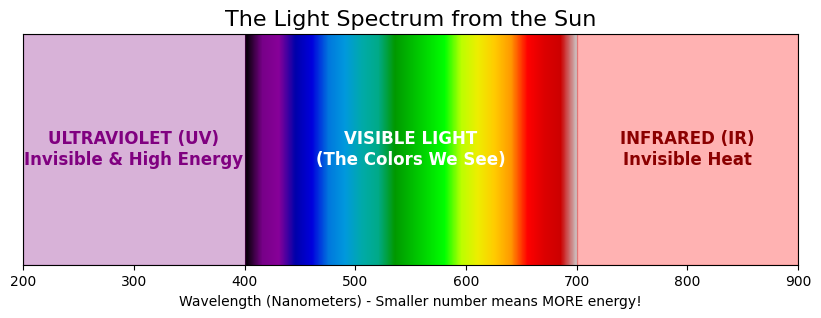

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def show_light_spectrum():
    """Visualizes the electromagnetic spectrum focusing on Visible vs. UV light."""
    fig, ax = plt.subplots(figsize=(10, 3))
    
    # Create a gradient for the visible spectrum
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))
    
    # Plot the rainbow (Visible Light)
    ax.imshow(gradient, aspect='auto', cmap='nipy_spectral', extent=[400, 700, 0, 1])
    
    # Add the Invisible UV section
    ax.add_patch(patches.Rectangle((200, 0), 200, 1, color='purple', alpha=0.3))
    ax.text(300, 0.5, "ULTRAVIOLET (UV)\nInvisible & High Energy", 
            color='purple', fontsize=12, fontweight='bold', ha='center', va='center')
    
    # Add the Invisible Infrared section
    ax.add_patch(patches.Rectangle((700, 0), 200, 1, color='red', alpha=0.3))
    ax.text(800, 0.5, "INFRARED (IR)\nInvisible Heat", 
            color='darkred', fontsize=12, fontweight='bold', ha='center', va='center')
    
    # Labels
    ax.text(550, 0.5, "VISIBLE LIGHT\n(The Colors We See)", 
            color='white', fontsize=12, fontweight='bold', ha='center', va='center')
    
    ax.set_xlim(200, 900)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Wavelength (Nanometers) - Smaller number means MORE energy!")
    ax.set_title("The Light Spectrum from the Sun", fontsize=16)
    
    plt.show()

# Run the spectrum simulator!
show_light_spectrum()

### 🔍 What is UV Light?
Look at the chart above. The rainbow is all the light our eyes can see. But to the left, there is **Ultraviolet (UV)** light. It has shorter waves, which means it carries **more energy**. 

That extra energy is exactly what our chemistry paper needs to change color!

---

### The Photochemistry Simulator
Now, let's simulate the three stages of a Cyanotype:
1. **The Paper:** Covered in iron chemicals (usually pale yellow/green).
2. **The Exposure:** The Sun's UV light hits the paper. It turns a muddy bronze color as the chemicals get excited.
3. **The Wash:** We wash it in water. The unexposed chemicals wash away (leaving white paper), and the exposed chemicals lock in as bright Prussian Blue!

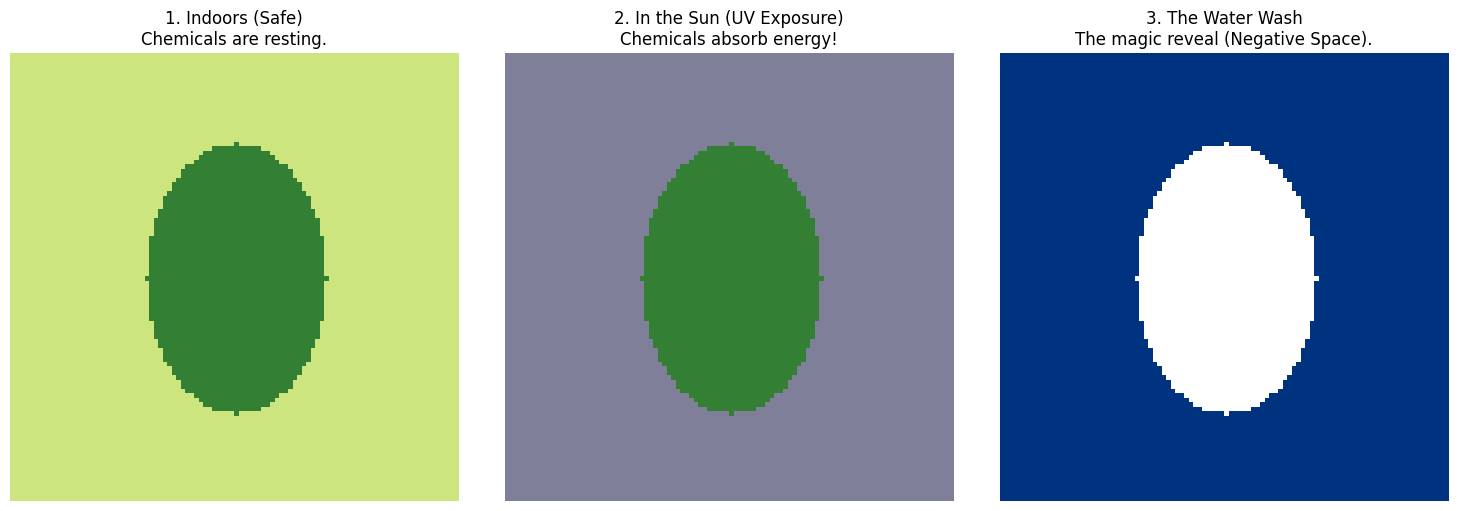

In [2]:
def simulate_cyanotype():
    """Simulates the three stages of the cyanotype chemical reaction."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Create a base grid (100x100)
    y, x = np.ogrid[0:100, 0:100]
    
    # Create a "Leaf" mask (True where the leaf is, False where it isn't)
    # Equation of an ellipse/leaf shape
    leaf_mask = ((x - 50)**2)/400 + ((y - 50)**2)/900 <= 1
    
    # --- STAGE 1: Unexposed Paper (Indoors) ---
    # Pale yellow-green color
    stage1 = np.zeros((100, 100, 3))
    stage1[:] = [0.8, 0.9, 0.5] # RGB for pale yellow-green
    
    # Put the leaf on top (Draw leaf as dark green)
    stage1[leaf_mask] = [0.2, 0.5, 0.2]
    
    axes[0].imshow(stage1)
    axes[0].set_title("1. Indoors (Safe)\nChemicals are resting.", fontsize=12)
    axes[0].axis('off')
    
    # --- STAGE 2: UV Exposure (In the Sun) ---
    # The paper turns a muddy bronze/grey color where the sun hits it
    stage2 = np.zeros((100, 100, 3))
    stage2[:] = [0.5, 0.5, 0.6] # RGB for muddy grey-blue
    
    # The leaf is still there blocking the sun!
    stage2[leaf_mask] = [0.2, 0.5, 0.2]
    
    axes[1].imshow(stage2)
    axes[1].set_title("2. In the Sun (UV Exposure)\nChemicals absorb energy!", fontsize=12)
    axes[1].axis('off')
    
    # --- STAGE 3: The Water Wash ---
    # Exposed areas turn bright Prussian Blue, unexposed wash away to White
    stage3 = np.zeros((100, 100, 3))
    stage3[:] = [0.0, 0.2, 0.5] # RGB for Prussian Blue
    
    # The area under the leaf washes away to white!
    stage3[leaf_mask] = [1.0, 1.0, 1.0] # White
    
    axes[2].imshow(stage3)
    axes[2].set_title("3. The Water Wash\nThe magic reveal (Negative Space).", fontsize=12)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the Cyanotype simulator!
simulate_cyanotype()

### 🎨 The Art Rule: Negative Space
Notice how the final picture doesn't actually show the leaf? It shows the shape of the *empty space* where the leaf used to be. 

* The white shape is the **Negative Space** (the shadow).
* The blue background is the **Positive Space** (where the UV light hit).

By understanding how invisible light causes chemical reactions, you have just become a photochemist!